# Part 4 - Tabular Data (MiniBooNE Particle Identification)
Neural networks, especially CNNs, work extremely well on images. However, on tabular data, they are not as effective (see [this paper](https://proceedings.neurips.cc/paper_files/paper/2022/hash/0378c7692da36807bdec87ab043cdadc-Abstract-Datasets_and_Benchmarks.html)). Tabular data has columns of features which can have different data types like numerical or categorical values.

In this task, the goal is to achieve well performing classifier on the tabular [MiniBoone dataset](https://archive.ics.uci.edu/dataset/199/miniboone+particle+identification). You can reuse all your code from part 3.

In [1]:
import requests
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import time

import pandas as pd
from scipy.io import arff

# Download MiniBooNE (ARFF)
download_data = [{
    "url": "https://www.dropbox.com/scl/fi/ht6ybxai15nzuf6jqczys/MiniBooNE.arff?rlkey=v69auyh8866mew4j02cet4b5m&st=nt0w9d74&dl=1",
    "file": "MiniBooNE.arff"
}]

root = Path("raw_miniboone")
root.mkdir(parents=True, exist_ok=True)
for d in download_data:
    p = root / d["file"]
    if not p.exists():
        r = requests.get(d["url"], timeout=60)
        r.raise_for_status()
        p.write_bytes(r.content)

# Load into DataFrame
miniboone_df = pd.DataFrame(arff.loadarff(root / "MiniBooNE.arff")[0])
display(miniboone_df.head())
print('Means:')
display(pd.DataFrame(miniboone_df.drop('signal', axis=1).mean()).transpose().head())

,signal,ParticleID_0,ParticleID_1,ParticleID_2,ParticleID_3,ParticleID_4,ParticleID_5,ParticleID_6,ParticleID_7,ParticleID_8,...,ParticleID_40,ParticleID_41,ParticleID_42,ParticleID_43,ParticleID_44,ParticleID_45,ParticleID_46,ParticleID_47,ParticleID_48,ParticleID_49
0,b'True',2.59413,0.468803,20.6916,0.322648,0.009682,0.374393,0.803479,0.896592,3.59665,...,101.174,-31.3730,0.442259,5.86453,0.000000,0.090519,0.176909,0.457585,0.071769,0.245996
1,b'True',3.86388,0.645781,18.1375,0.233529,0.030733,0.361239,1.069740,0.878714,3.59243,...,186.516,45.9597,-0.478507,6.11126,0.001182,0.091800,-0.465572,0.935523,0.333613,0.230621
2,b'True',3.38584,1.197140,36.0807,0.200866,0.017341,0.260841,1.108950,0.884405,3.43159,...,129.931,-11.5608,-0.297008,8.27204,0.003854,0.141721,-0.210559,1.013450,0.255512,0.180901
3,b'True',4.28524,0.510155,674.2010,0.281923,0.009174,0.000000,0.998822,0.823390,3.16382,...,163.978,-18.4586,0.453886,2.48112,0.000000,0.180938,0.407968,4.341270,0.473081,0.258990
4,b'True',5.93662,0.832993,59.8796,0.232853,0.025066,0.233556,1.370040,0.787424,3.66546,...,229.555,42.9600,-0.975752,2.66109,0.000000,0.170836,-0.814403,4.679490,1.924990,0.253893


Means:


,ParticleID_0,ParticleID_1,ParticleID_2,ParticleID_3,ParticleID_4,ParticleID_5,ParticleID_6,ParticleID_7,ParticleID_8,ParticleID_9,...,ParticleID_40,ParticleID_41,ParticleID_42,ParticleID_43,ParticleID_44,ParticleID_45,ParticleID_46,ParticleID_47,ParticleID_48,ParticleID_49
0,1.251799,-2.107551,123.795041,-3.312518,-3.585353,-3.434412,-2.627901,-2.773691,-0.15568,-3.421357,...,141.180058,-25.225963,-2.863924,2.393149,-3.585605,-3.416491,-3.753232,-0.744964,-1.987056,-3.364752


In [2]:
# Convert to numpy data and labels
X_unfiltered = miniboone_df.drop(columns="signal").to_numpy()
y_unfiltered = (miniboone_df["signal"] == b'True').to_numpy().astype(int)

print(f"{X_unfiltered.shape = }")
print(f"{y_unfiltered.shape = }")
print(f"Unique signal values: {miniboone_df['signal'].unique()}")

X_unfiltered.shape = (130064, 50)
y_unfiltered.shape = (130064,)
Unique signal values: [b'True' b'False']


In [3]:
# Convert (map) loaded bytes (corresponding to strings "True" and "False") to real bool True and False
# If cell is rerun, we want to keep bool True and False as is
miniboone_df['signal'] = miniboone_df['signal'].map({
    b"True": True,
    b"False": False,
    True: True,
    False: False
})

print(f"Unique signal values: {miniboone_df['signal'].unique()}")

Unique signal values: [ True False]


## 4.1 Familiarize Yourself with the Data
Read the dataset description and analyze the data.
- Identify and filter out invalid samples: Locate all the rows where all features (columns) have the value -999. Remove them.
- Split the filtered data into training and testing sets. Use 20% of the data for testing and set the `random_state` to 42. Use the [train_test_split function from scikit-learn](https://scikit-learn.org/1.5/modules/generated/sklearn.model_selection.train_test_split.html).
- Which normalization method would you use for this dataset? Why?
- Which metrics would you use to evaluate the model?

---

Filtering out the invalid samples are simple pandas data frame operations (seen below).
Splitting the data is also simply done below.

To normalize the data, we decided to normalize over each feature (column) separately.
This is because we have no reason to assume the features have relations to each other.
We see this already in the means of the `ParticleID_i` columns ($i = 0, 1, 2$) (see above).
The means of the first values are about $1$, $-2$ and $124$, showing that not even the order of magnitude is comparable.
Normalizing over all columns at the same time with one average would "destroy" or "wash out" the features with small values.
Therefore, we normalize each feature separately, leaving us with $50$ different means and standard deviations, one for each feature column.
We print these below to check our code.



EXPLAIN METRICS (skript)

In [4]:
# get columns except for first (signal) column
particleID_cols = miniboone_df.columns[1:]
# identify invalid samples
mask_is_invalid = (miniboone_df[particleID_cols].eq(-999).all(axis=1))
# filter out invalid samples
filtered_df = miniboone_df[~mask_is_invalid]

print(f'Indices of invalid values:\n{mask_is_invalid[mask_is_invalid].index}')

Indices of invalid values:
Index([ 15610,  15758,  19652,  23229,  23632,  24094,  24517,  27271,  27374,
        31832,
       ...
       128354, 128407, 128532, 128747, 128757, 128993, 129265, 129623, 129687,
       130043],
      dtype='int64', length=468)


In [5]:
train_dataset, test_dataset = train_test_split(filtered_df, test_size=0.2, random_state=42)
print(f'Original: {filtered_df.shape}')
print(f'Training: {train_dataset.shape}')
print(f'Testing:  {test_dataset.shape}')

Original: (129596, 51)
Training: (103676, 51)
Testing:  (25920, 51)


In [6]:
from sklearn.preprocessing import StandardScaler
standard_scaler = StandardScaler()

y_train = train_dataset['signal']
y_test = test_dataset['signal']

X_train = standard_scaler.fit_transform(train_dataset[particleID_cols])
X_test = standard_scaler.transform(test_dataset[particleID_cols])

# check shapes of normalization parameters, see that we are normalizing over each column
print(f'Means shape:              {standard_scaler.mean_.shape}')
print(f'Standard Deviation shape: {standard_scaler.scale_.shape}')

Means shape:              (50,)
Standard Deviation shape: (50,)


## 4.2 Classical Machine Learning
- Try to achieve a high classification accuracy using non-neural network methods.
You should aim for at least 0.937 accuracy.
Discuss the results.

---



In [7]:
from tqdm.notebook import tqdm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

classifiers = [
    ('k-nn', KNeighborsClassifier(n_neighbors=5)),
    ('Random Forest', RandomForestClassifier(n_estimators=200, max_depth=20, max_features=20, n_jobs=-1)),
    ('HGBC', HistGradientBoostingClassifier(max_iter=1000, learning_rate=0.1, max_depth=10))
]

results: list[dict] = []
for (name, clf) in tqdm(classifiers):
    tr_st = time.time()
    clf.fit(X_train, y_train)
    tr_et = time.time()
    te_st = time.time()
    score = clf.score(X_test, y_test)
    te_et = time.time()
    results.append({
        'name': name,
        'accuracy': score,
        'training_runtime': tr_et - tr_st,
        'testing_runtime': te_et - te_st
    })

df = pd.DataFrame(results)
display(df)

  0%|          | 0/3 [00:00<?, ?it/s]

,name,accuracy,training_runtime,testing_runtime
0,k-nn,0.929051,0.017682,2.189137
1,Random Forest,0.937693,57.351822,0.083129
2,HGBC,0.944290,3.381337,0.060802


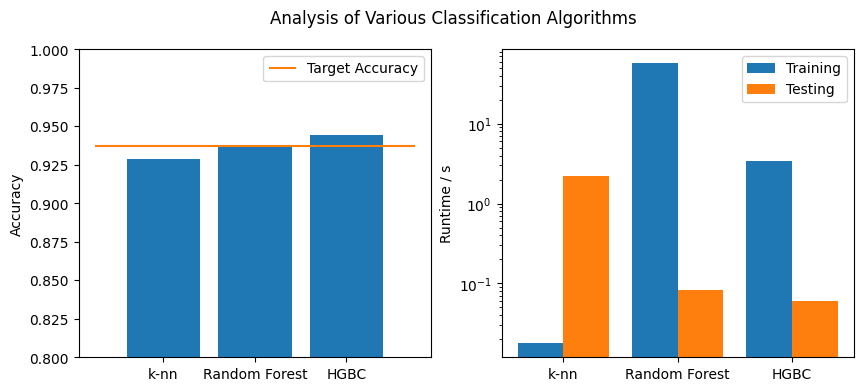

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(2*5, 4))
ax1, ax2 = axes
ax1.bar(df['name'], df['accuracy'])
ax1.set_ylim(0.8, 1)
ax1.hlines(0.937, -0.75, 2.75, colors='tab:orange', label='Target Accuracy')
ax1.set_ylabel('Accuracy')
ax1.legend()

bar_pos = np.arange(len(df))
width = 0.8/2

ax2.bar(bar_pos - width/2, df['training_runtime'], width, label='Training')
ax2.bar(bar_pos + width/2, df['testing_runtime'], width, label='Testing')
ax2.set_yscale('log')
ax2.set_xticks(bar_pos)
ax2.set_xticklabels(df['name'])
ax2.set_ylabel('Runtime / s')
ax2.legend()

fig.suptitle('Analysis of Various Classification Algorithms')
plt.show()

## 4.3 Neural Networks
- Try to get a high classification accuracy using neural networks.
- See how your neural networks perform compared to your previously used methods.

---

